# 5. Semi-Supervised CNN - Pavia University (Self-Training)

X_train'in küçük bir kısmı etiketli (labeled), geri kalanı etiketsiz (unlabeled) olarak kullanılır.
Model her iterasyonda yüksek güvenli tahminleri pseudo-label olarak etiketli sete ekler.

### Adım 1: Google Colab ve Google Drive Hazırlığı

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("✅ Google Colab ortamı algılandı. Drive başarıyla bağlandı.")
except ModuleNotFoundError:
    IN_COLAB = False
    print("💻 Lokal ortam algılandı.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Colab ortamı algılandı. Drive başarıyla bağlandı.


### Adım 2: Gerekli Kütüphanelerin Yüklenmesi

In [2]:
if IN_COLAB:
    !pip install -q torch torchvision scikit-learn seaborn matplotlib

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


### Adım 3: Verilerin Yüklenmesi

In [3]:
if IN_COLAB:
    PROCESSED_DIR = '/content/drive/MyDrive/datasets/processed'
else:
    PROCESSED_DIR = './datasets/processed'

dataset_prefix = 'pavia_university_gauss0.5_pca30'

X_train = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_X_train.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_y_train.npy'))
X_test  = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_X_test.npy'))
y_test  = np.load(os.path.join(PROCESSED_DIR, f'{dataset_prefix}_y_test.npy'))

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (34220, 15, 15, 30), X_test: (8556, 15, 15, 30)


### Adım 4: Etiketli / Etiketsiz Set Ayrımı

X_train'in %10'u etiketli (labeled), %90'ı etiketsiz (unlabeled) olarak ayrılır.
Stratified split ile her sınıfın oranı korunur.

In [4]:
from sklearn.model_selection import train_test_split

LABELED_RATIO = 0.10

X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(
    X_train, y_train,
    train_size=LABELED_RATIO,
    stratify=y_train,
    random_state=42
)

print(f"Etiketli  : {X_labeled.shape[0]} örnek")
print(f"Etiketsiz : {X_unlabeled.shape[0]} örnek")
print(f"Test      : {X_test.shape[0]} örnek")

Etiketli  : 3422 örnek
Etiketsiz : 30798 örnek
Test      : 8556 örnek


### Adım 5: Model Tanımı ve Hiperparametreler

Supervised CNN ile aynı mimari kullanılır.

In [5]:
class HSI_CNN(nn.Module):
    def __init__(self, num_classes, input_channels=30):
        super(HSI_CNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.fc_block = nn.Sequential(
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)
        return self.fc_block(x)


def to_tensor(X, y, zero_index=True):
    X_t = torch.tensor(np.transpose(X, (0, 3, 1, 2)), dtype=torch.float32)
    y_t = torch.tensor(y - 1 if zero_index else y, dtype=torch.long)
    return X_t, y_t


num_classes     = len(np.unique(y_train))
BATCH_SIZE      = 64
NUM_EPOCHS      = 30
CONFIDENCE_THR  = 0.95
MAX_ITERATIONS  = 10

print(f"Sınıf sayısı: {num_classes}")

Sınıf sayısı: 9


### Adım 6: Self-Training Döngüsü (Curriculum Learning ile)

Her iterasyonda:
1. Mevcut etiketli set üzerinde CNN eğitilir
2. Etiketsiz örneklere softmax olasılıkları hesaplanır
3. `CONFIDENCE_THR` üstündeki örnekler güven skoruna göre sıralanır (Curriculum: kolay önce)
4. Pseudo-label olarak etiketli sete eklenir, etiketsiz pooldan çıkarılır
5. Test seti üzerinde değerlendirme yapılır

In [6]:
def train_model(model, X, y, epochs=NUM_EPOCHS):
    X_t, y_t = to_tensor(X, y)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=BATCH_SIZE, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for _ in range(epochs):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()


def predict_proba(model, X):
    model.eval()
    X_t = torch.tensor(np.transpose(X, (0, 3, 1, 2)), dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_t), batch_size=BATCH_SIZE, shuffle=False)
    probs = []
    with torch.no_grad():
        for (inputs,) in loader:
            logits = model(inputs.to(device))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(probs, axis=0)


def evaluate(model, X, y):
    probs = predict_proba(model, X)
    preds = np.argmax(probs, axis=1) + 1
    return {
        'Accuracy':  accuracy_score(y, preds) * 100,
        'Precision': precision_score(y, preds, average='macro', zero_division=0) * 100,
        'Recall':    recall_score(y, preds, average='macro', zero_division=0) * 100,
        'F1-Score':  f1_score(y, preds, average='macro', zero_division=0) * 100,
        'Kappa':     cohen_kappa_score(y, preds) * 100,
    }, preds


X_lbl = X_labeled.copy()
y_lbl = y_labeled.copy()
X_unl = X_unlabeled.copy()

iteration_results = []

for iteration in range(MAX_ITERATIONS):
    if X_unl.shape[0] == 0:
        print(f"Iterasyon {iteration+1}: Etiketsiz pool tükendi, durduruluyor.")
        break

    model = HSI_CNN(num_classes=num_classes).to(device)
    train_model(model, X_lbl, y_lbl)

    probs = predict_proba(model, X_unl)
    max_probs = probs.max(axis=1)
    pseudo_labels = np.argmax(probs, axis=1) + 1

    confident_mask = max_probs >= CONFIDENCE_THR
    confident_idx  = np.where(confident_mask)[0]
    confident_idx  = confident_idx[np.argsort(max_probs[confident_idx])[::-1]]

    metrics, _ = evaluate(model, X_test, y_test)
    metrics['Iteration'] = f'Iter {iteration+1}'
    metrics['Labeled']   = X_lbl.shape[0]
    metrics['Pseudo Added'] = len(confident_idx)
    iteration_results.append(metrics)

    print(f"Iter {iteration+1} | Etiketli: {X_lbl.shape[0]} | "
          f"Pseudo eklendi: {len(confident_idx)} | "
          f"Acc: %{metrics['Accuracy']:.2f}")

    if len(confident_idx) == 0:
        print("Yeni pseudo-label yok, erken duruluyor.")
        break

    X_lbl = np.concatenate([X_lbl, X_unl[confident_idx]], axis=0)
    y_lbl = np.concatenate([y_lbl, pseudo_labels[confident_idx]], axis=0)
    X_unl = np.delete(X_unl, confident_idx, axis=0)

Iter 1 | Etiketli: 3422 | Pseudo eklendi: 30719 | Acc: %99.94
Iter 2 | Etiketli: 34141 | Pseudo eklendi: 76 | Acc: %99.99
Iter 3 | Etiketli: 34217 | Pseudo eklendi: 3 | Acc: %99.99
Iterasyon 4: Etiketsiz pool tükendi, durduruluyor.


### Adım 7: Sonuçların Gösterilmesi

In [7]:
df = pd.DataFrame(iteration_results).set_index('Iteration')
display(df[['Labeled', 'Pseudo Added', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Kappa']].round(2))

,Labeled,Pseudo Added,Accuracy,Precision,Recall,F1-Score,Kappa
Iteration,,,,,,,
Iter 1,3422,30719,99.94,99.95,99.87,99.91,99.92
Iter 2,34141,76,99.99,99.98,99.99,99.99,99.98
Iter 3,34217,3,99.99,100.00,99.98,99.99,99.98


### Adım 8: Görselleştirme

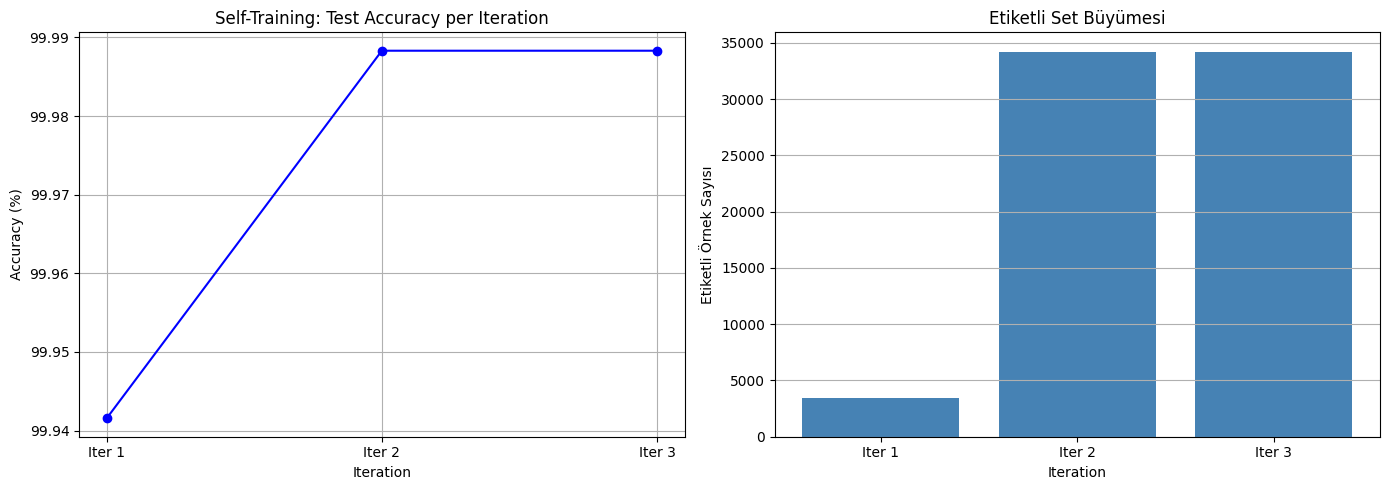

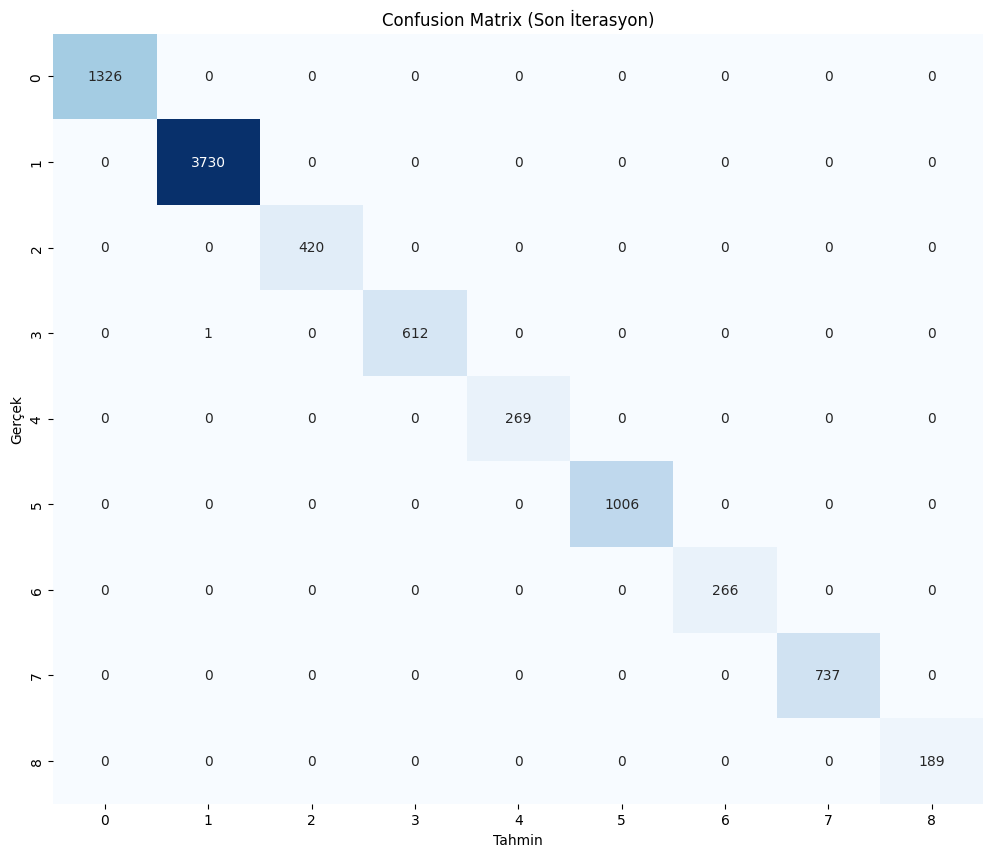

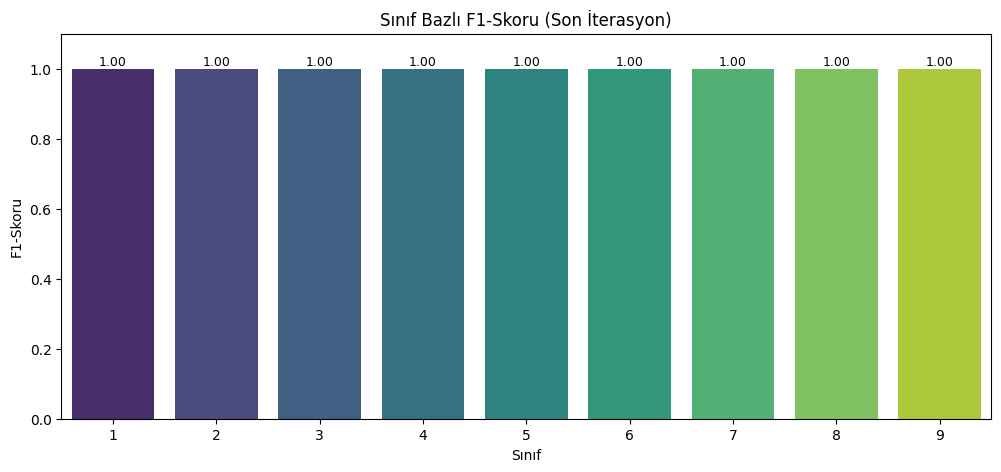

In [8]:
iterations = [r['Iteration'] for r in iteration_results]
accuracies = [r['Accuracy'] for r in iteration_results]
labeled_counts = [r['Labeled'] for r in iteration_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(iterations, accuracies, 'b-o')
axes[0].set_title('Self-Training: Test Accuracy per Iteration')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Accuracy (%)')
axes[0].grid(True)

axes[1].bar(iterations, labeled_counts, color='steelblue')
axes[1].set_title('Etiketli Set Büyümesi')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Etiketli Örnek Sayısı')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

_, final_preds = evaluate(model, X_test, y_test)
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Son İterasyon)')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.show()

report = classification_report(y_test, final_preds, output_dict=True)
classes = [k for k in report.keys() if k.isdigit()]
f1_scores = [report[k]['f1-score'] for k in classes]

plt.figure(figsize=(12, 5))
sns.barplot(x=classes, y=f1_scores, hue=classes, palette='viridis', dodge=False, legend=False)
plt.title('Sınıf Bazlı F1-Skoru (Son İterasyon)')
plt.xlabel('Sınıf')
plt.ylabel('F1-Skoru')
plt.ylim(0, 1.1)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.show()

### Adım 9: Model Kaydı

In [9]:
import shutil

model_save_path = f'semi_cnn_model_{dataset_prefix}.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model kaydedildi: {model_save_path}")

if IN_COLAB:
    drive_save_path = f'/content/drive/MyDrive/models/{model_save_path}'
    os.makedirs(os.path.dirname(drive_save_path), exist_ok=True)
    shutil.copy(model_save_path, drive_save_path)
    print(f"Drive'a kopyalandı: {drive_save_path}")

Model kaydedildi: semi_cnn_model_pavia_university_gauss0.5_pca30.pth
Drive'a kopyalandı: /content/drive/MyDrive/models/semi_cnn_model_pavia_university_gauss0.5_pca30.pth
